<h1><center>Laboratorio 4: EDA en Pandas 🐼</center></h1>

<center><strong>MDS7202: Laboratorio de Programación Científica para Ciencia de Datos</strong></center>

### Cuerpo Docente:

- Profesores: Pablo Badilla, Diego Cortez
- Auxiliares: Melanie Peña, Valentina Rojas
- Ayudantes: Javiera Arévalo, Tamara Carrasco y Ignacio Reyes

### Equipo: SUPER IMPORTANTE - notebooks sin nombre no serán revisados

- Nombre de alumno 1: Gonzalo Sobarzo   
- Nombre de alumno 2: Bryan Cabezas


### **Link de repositorio de GitHub:** `https://github.com/BAFCS/MDS7202`


## Reglas:

- **Grupos de 2 personas**
- Asistencia **obligatoria** a instrucciones del lab (viernes 16.15). Luego, pueden quedarse trabajando en las salas o irse.
- **No se revisarán entregas de personas ausentes**. 
- Cualquier duda fuera del horario de clases al foro. Mensajes al equipo docente serán respondidos por este medio.
- Prohibidas las copias. 
- Pueden usar cualquer matrial del curso que estimen conveniente.

### Objetivos principales del laboratorio

- Aplicar los paradigmas y buenas prácticas de programación vistas hasta este momento.
- Utilizar las funciones de la librería `pandas` para realizar análisis exploratorio de datos
- Aplicar principios de visualización de datos vistos en clases para mostrar patrones en los datos


El laboratorio deberá ser desarrollado sin el uso indiscriminado de iteradores nativos de python (aka "for", "while"). La idea es que aprendan a exprimir al máximo las funciones optimizadas de `pandas`.

## Descripción del laboratorio.

### Importamos librerias utiles 😸

In [3]:
!uv pip install missingno

Using Python 3.14.3 environment at: C:\Users\pc\Desktop\MDS\Lab ciencia de datos\Repo\MDS7202\.venv
Resolved 16 packages in 3.17s
Prepared 2 packages in 461ms
Installed 2 packages in 89ms
 + missingno==0.5.2
 + seaborn==0.13.2


In [4]:
# Libreria Core del lab.

# Libreria para plotear
import matplotlib.pyplot as plt
import missingno as msno
import numpy as np
import pandas as pd
import plotly.express as px
from IPython.display import Markdown, display
from scipy import stats

# Segmentación de Clientes en Tienda de Retail 🛍️

<p align="center">
  <img width=300 src="https://s1.eestatic.com/2018/04/14/social/la_jungla_-_social_299733421_73842361_854x640.jpg">
</p>

## 1.1 Cargar dataset [0.5 puntos]

Mr. Lepin Mora quien es el gerente de una cotizada tienda de retail en Europa, les solicita si pueden analizar los datos de algunas de sus tiendas.

Para esto, el área de ventas les entrega el 2 archivos: `online_retail_II.pickle` y `online_retail_I.pickle`.
- Cargue ambas fuentes y asegúrese que las columnas son del tipo correcto como en el ejemplo de df_retail_1 visualizando los datos para determinar el tipo. Para fechas, puede usar `'datetime64[ns]'`
- Combine los dataframes en uno solo. ¿Qué función debe utilizar en este caso?
- Señale las columnas que componen el dataset combinado, el tipo de variable presente en cada columna y comente que representa cada una de estas.

**Respuesta:**

In [5]:
df_retail_1 = pd.read_pickle("online_retail_I.pickle")
df_retail_1 = df_retail_1.astype(
    {
        "Invoice": "category",
        "StockCode": "category",
        "Description": str,
        "Customer ID": "category",
    }
)
df_retail_1.head()

,Invoice,StockCode,Description,Quantity,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,1.25,13085.0,United Kingdom


In [6]:
df_retail_1["Invoice"].duplicated().sum()

np.int64(496645)

In [7]:
df_retail_1.info()

<class 'pandas.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype   
---  ------       --------------   -----   
 0   Invoice      525461 non-null  category
 1   StockCode    525461 non-null  category
 2   Description  522533 non-null  str     
 3   Quantity     525461 non-null  int64   
 4   Price        525461 non-null  float64 
 5   Customer ID  417534 non-null  category
 6   Country      525461 non-null  object  
dtypes: category(3), float64(1), int64(1), object(1), str(1)
memory usage: 20.5+ MB


In [18]:
df_retail_1.shape

(525461, 7)

In [8]:
df_retail_2 = pd.read_pickle("online_retail_II.pickle")
df_retail_2 = df_retail_2.astype({"Invoice": "category", "InvoiceDate": "datetime64[ns]"})
df_retail_2.head()
# Resto de su código

,Invoice,InvoiceDate
0,489434,2009-12-01 07:45:00
1,489435,2009-12-01 07:46:00
2,489436,2009-12-01 09:06:00
3,489437,2009-12-01 09:08:00
4,489438,2009-12-01 09:24:00


In [14]:
df_retail_2.info()

<class 'pandas.DataFrame'>
RangeIndex: 28816 entries, 0 to 28815
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Invoice      28816 non-null  category      
 1   InvoiceDate  28816 non-null  datetime64[ns]
dtypes: category(1), datetime64[ns](1)
memory usage: 1.5 MB


In [19]:
df_retail_2.shape

(28816, 2)

In [9]:
# Combinar dataframes
df_retail = pd.merge(df_retail_1, df_retail_2, how="left", on="Invoice")
df_retail

,Invoice,StockCode,Description,Quantity,Price,Customer ID,Country,InvoiceDate
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,6.95,13085.0,United Kingdom,2009-12-01 07:45:00
1,489434,79323P,PINK CHERRY LIGHTS,12,6.75,13085.0,United Kingdom,2009-12-01 07:45:00
2,489434,79323W,WHITE CHERRY LIGHTS,12,6.75,13085.0,United Kingdom,2009-12-01 07:45:00
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2.10,13085.0,United Kingdom,2009-12-01 07:45:00
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,1.25,13085.0,United Kingdom,2009-12-01 07:45:00
...,...,...,...,...,...,...,...,...
525456,538171,22271,FELTCRAFT DOLL ROSIE,2,2.95,17530.0,United Kingdom,2010-12-09 20:01:00
525457,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1,3.75,17530.0,United Kingdom,2010-12-09 20:01:00
525458,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1,3.75,17530.0,United Kingdom,2010-12-09 20:01:00
525459,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2,3.75,17530.0,United Kingdom,2010-12-09 20:01:00


In [25]:
df_retail["Country"].value_counts()

Country
United Kingdom          485852
EIRE                      9670
Germany                   8129
France                    5772
Netherlands               2769
Spain                     1278
Switzerland               1187
Portugal                  1101
Belgium                   1054
Channel Islands            906
Sweden                     902
Italy                      731
Australia                  654
Cyprus                     554
Austria                    537
Greece                     517
United Arab Emirates       432
Denmark                    428
Norway                     369
Finland                    354
Unspecified                310
USA                        244
Japan                      224
Poland                     194
Malta                      172
Lithuania                  154
Singapore                  117
RSA                        111
Bahrain                    107
Canada                      77
Hong Kong                   76
Thailand                    76


In [24]:
df_retail.info()

<class 'pandas.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  category      
 1   StockCode    525461 non-null  category      
 2   Description  522533 non-null  str           
 3   Quantity     525461 non-null  int64         
 4   Price        525461 non-null  float64       
 5   Customer ID  417534 non-null  category      
 6   Country      525461 non-null  object        
 7   InvoiceDate  525461 non-null  datetime64[ns]
dtypes: category(3), datetime64[ns](1), float64(1), int64(1), object(1), str(1)
memory usage: 24.5+ MB


### Respuestas

- Para combinar ambos dataframes se utilizó el metodo merge, la cual permite combinar mediante Invoice, el cual se repite en ambos dataframes. Además, se configuro el hiperparametro de join con LEFT JOIN, manteniendo todas las facturas del dataframe principal (para no perder ninguna), agregando la fecha del segundo dataframe en caso de existir, de lo contrario agregando un NaN. Esto permite mantener toda la información de las facturas, inclusive si no se presenta la fecha que ocurrio.

- El nuevo dataframe 'df_retail' se compone de 525.461 filas y 8 columnas. Las columnas son:
    - Invoice: Número de factura. Se define como tipo categórico ya que corresponde a un identificador y no a una variable numérica. Además, al presentar valores repetidos (una misma factura puede aparecer en múltiples filas), este tipo permite optimizar el uso de memoria y mejorar la eficiencia en operaciones como agrupaciones. No se utiliza para realizar cálculos matemáticos.
    - StockCode: Código del stock. Tipo Categórico, nuevamente un identificar de Stock.
    - Descripcion: Descripción del producto facturado. Se define como tipo string, al ser solo un texto.
    - Quantity: Cantidad facturas del producto. Se define como un tipo int64, ya que presenta valores enteros.
    - Price: Precio del producto. Se define como un tipo float64, mediante un precio decimal.
    - Customer ID: Identificador del cliente de la factura. Se define como un tipo categórico al ser un identificador.
    - Country: País del cliente. Se define como tipo object, guardando el texto de cada celda, sin optimización y utilizando más memoria. Este es el metodo default de pandas que representa las cadenas de texto.
    - InvoiceDate: Fecha y hora que se generó al factura. Se define como tipo datetime64, es decir tipo fecha y hora.

## 1.2 Analisís Explotatorio de los Datos [0.5 puntos] 

En base a la primera visualización del dataset, *Don Mora* le solicita que realicen un análisis exploratorio de los datos, para esto les deberán realizar un análisis univariado y multivariado. De la revisión, ustedes deben explicar potenciales anomalías visualizadas y señalar si existe la necesidad de realizar una limpieza de datos.

Explique a que nos referimos con análisis univariable, multivariable y de datos faltantes. ¿Qué beneficios nos otorga estudiar estos datos?. Sea conciso con su respuesta y no escriba mas de 5 líneas para su respuesta.

**Respuesta a la Pregunta:**

> El análisis univariado estudia cada variable de forma individual, permitiendo conocer su distribución y detectar valores atípicos o nulos. El análisis multivariado examina la relación entre dos o más variables, identificando patrones, diferencias o correlaciones. El análisis de datos faltantes permite detectar valores ausentes y decidir si imputarlos o eliminarlos. En conjunto, estos análisis mejoran la comprensión, calidad y preparación de los datos.


### 1.2.1 Análisis Univariado [1.5 Puntos]

A continuación, se le presentan dos funciones para analizar los datos que componen un dataframe. La primera de estas es la función ``profile_serie()`` la cual recibe una serie y le entrega un análisis detallado de los datos que conforman dicha serie. 

Ejecute la funcion ``profile_serie()`` sobre cada serie para realizar un análisis univariado de estas. A continuación, comente acerca de el comportamiento de cada variable según las estadísticas descriptivas y los gráficos generados.

In [10]:
from pandas.api.types import is_datetime64_any_dtype, is_numeric_dtype, is_timedelta64_dtype


def profile_serie(serie_in, n_samples=1000, random_state=42):
    serie = serie_in.copy()

    profile = pd.Series(dtype="object")
    profile["Type"] = serie.dtype
    profile = pd.concat([profile, serie.describe()])

    # profile = pd.Series([])

    if is_numeric_dtype(serie):
        profile["Negative"] = (serie < 0).sum()
        profile["Negative (%)"] = str(round((serie < 0).sum() / len(serie) * 100, 2)) + " %"
        profile["Zeros"] = (serie == 0).sum()
        profile["Zeros (%)"] = str(round((serie == 0).sum() / len(serie) * 100, 2)) + " %"
        profile["Kurt"] = serie.kurt()
        profile["Skew"] = serie.skew()

    profile[" "] = " "  # espacio

    profile["Missing cells"] = serie.isnull().sum()
    profile["Missing cells (%)"] = str(round(serie.isnull().sum() / len(serie) * 100, 2)) + " %"
    profile["Duplicate rows"] = serie.duplicated(False).sum()
    profile["Duplicate rows (%)"] = str(round(serie.duplicated(False).sum() / len(serie) * 100, 2)) + " %"
    profile["Total size in memory"] = str(serie.memory_usage(index=True)) + " bytes"

    # profile = pd.concat([profile, description])

    profile = profile.rename(
        index={
            "count": "Number of observations",
            "mean": "Mean",
            "std": "Std",
            "min": "Min",
            "max": "Max",
            "unique": "Unique",
            "top": "Top",
            "freq": "Freq",
        }
    )
    no_outliers_fig = None

    if is_numeric_dtype(serie):
        sampled_serie = serie.sample(n_samples, random_state=random_state)
        fig = px.histogram(sampled_serie, marginal="box", title=f"{serie.name} - With Outliers")

        no_outliers = sampled_serie.loc[(np.abs(stats.zscore(sampled_serie)) < 3)]
        # zscore = https://es.wikipedia.org/wiki/Unidad_tipificada

        no_outliers_fig = px.histogram(no_outliers, marginal="box", title=f"{serie.name} - Without Outliers")

    elif is_datetime64_any_dtype(serie) or is_timedelta64_dtype(serie):
        sampled_serie = serie.sample(n_samples, random_state=random_state)
        fig = px.histogram(sampled_serie, marginal="box", title=f"{serie.name}")

    else:
        count = serie.value_counts()[0:100].reset_index().rename(columns={"count": "Count"})
        fig = px.bar(
            x=count[serie.name].astype(str),
            y=count["Count"],
            title=f"100 Most common categories of {serie.name}",
        )
    display(Markdown(f"## {serie.name} Profile"))
    display(profile)
    fig.show()

    if no_outliers_fig:
        no_outliers_fig.show()

    # return fig, profile

In [11]:
df_retail.loc[df_retail["Price"] < 0]

,Invoice,StockCode,Description,Quantity,Price,Customer ID,Country,InvoiceDate
179403,A506401,B,Adjust bad debt,1,-53594.36,NaN,United Kingdom,2010-04-29 13:36:00
276274,A516228,B,Adjust bad debt,1,-44031.79,NaN,United Kingdom,2010-07-19 11:24:00
403472,A528059,B,Adjust bad debt,1,-38925.87,NaN,United Kingdom,2010-10-20 12:04:00


In [12]:
profile_serie(df_retail["Price"])

## Price Profile

Type                            float64
Number of observations         525461.0
Mean                           4.688834
Std                          146.126914
Min                           -53594.36
25%                                1.25
50%                                 2.1
75%                                4.21
Max                            25111.09
Negative                              3
Negative (%)                      0.0 %
Zeros                              3687
Zeros (%)                         0.7 %
Kurt                       64868.344873
Skew                        -140.768446
                                       
Missing cells                         0
Missing cells (%)                 0.0 %
Duplicate rows                   524485
Duplicate rows (%)              99.81 %
Total size in memory      4203820 bytes
dtype: object

    Se observa que la variable Price es de tipo numérico decimal (float) y presenta 525.461 observaciones, con un promedio de 4.69. Se observan valores extremos, con un mínimo de -53.594 y un máximo de 25.111. lo que indica presencia de outliers. Existen 3 valores negativos, asociados a ajustes, y un 0.7% de precios iguales a cero, que podrían corresponder a errores o promociones. La distribución presenta alta asímetria y curtosis, lo cual se muestra en el histograma, visualizando una fuerte concentración en valores bajos (skew < 0) y algunos valores extremos (los negativos y outliers por kurt alta), como en el boxplot. Además, no se observan datos faltantes. Como también, el 75% de los datos se situan en el precio 4.21 o menos. Por último se muestra que al descartar los outliers mediante valores alejados en tres z_score, se observa una disminución del efecto en valores extremos, visualizando de mejor manera la distribución real, donde los precios se concentran entre 0 y 10 aprox.

In [32]:
profile_serie(df_retail["Invoice"])

## Invoice Profile

Type                           category
Number of observations           525461
Unique                            28816
Top                              537434
Freq                                675
                                       
Missing cells                         0
Missing cells (%)                 0.0 %
Duplicate rows                   517456
Duplicate rows (%)              98.48 %
Total size in memory      2338390 bytes
dtype: object

    Análisis de la primera serie...

In [ ]:
profile_serie(df_retail["StockCode"])

## StockCode Profile

Type                           category
Number of observations           525461
Unique                             4632
Top                              85123A
Freq                               3516
                                       
Missing cells                         0
Missing cells (%)                 0.0 %
Duplicate rows                   525026
Duplicate rows (%)              99.92 %
Total size in memory      1220246 bytes
dtype: object

    Análisis de la primera serie...

In [34]:
profile_serie(df_retail["Description"])

## Description Profile

Type                                                     str
Number of observations                                522533
Unique                                                  4681
Top                       WHITE HANGING HEART T-LIGHT HOLDER
Freq                                                    3549
                                                            
Missing cells                                           2928
Missing cells (%)                                     0.56 %
Duplicate rows                                        525198
Duplicate rows (%)                                   99.95 %
Total size in memory                           4203820 bytes
dtype: object

    Análisis de la primera serie...

In [35]:
profile_serie(df_retail["Quantity"])

## Quantity Profile

Type                              int64
Number of observations         525461.0
Mean                          10.337667
Std                           107.42411
Min                             -9600.0
25%                                 1.0
50%                                 3.0
75%                                10.0
Max                             19152.0
Negative                          12326
Negative (%)                     2.35 %
Zeros                                 0
Zeros (%)                         0.0 %
Kurt                        6277.666908
Skew                          36.044617
                                       
Missing cells                         0
Missing cells (%)                 0.0 %
Duplicate rows                   525122
Duplicate rows (%)              99.94 %
Total size in memory      4203820 bytes
dtype: object

    Análisis de la primera serie...

In [36]:
profile_serie(df_retail["Customer ID"])

## Customer ID Profile

Type                           category
Number of observations         417534.0
Unique                           4383.0
Top                             14911.0
Freq                             5710.0
                                       
Missing cells                    107927
Missing cells (%)               20.54 %
Duplicate rows                   525327
Duplicate rows (%)              99.97 %
Total size in memory      1086118 bytes
dtype: object

    Análisis de la primera serie...

In [37]:
profile_serie(df_retail["Country"])

## Country Profile

Type                              object
Number of observations            525461
Unique                                40
Top                       United Kingdom
Freq                              485852
                                        
Missing cells                          0
Missing cells (%)                  0.0 %
Duplicate rows                    525461
Duplicate rows (%)               100.0 %
Total size in memory       4203820 bytes
dtype: object

    Análisis de la primera serie...

In [38]:
profile_serie(df_retail["InvoiceDate"])

## InvoiceDate Profile

Type                                     datetime64[ns]
Number of observations                           525461
Mean                      2010-06-28 11:37:36.619958528
Min                                 2009-12-01 07:45:00
25%                                 2010-03-21 12:20:00
50%                                 2010-07-06 09:51:00
75%                                 2010-10-15 12:45:00
Max                                 2010-12-09 20:01:00
                                                       
Missing cells                                         0
Missing cells (%)                                 0.0 %
Duplicate rows                                   520408
Duplicate rows (%)                              99.04 %
Total size in memory                      4203820 bytes
dtype: object

    Análisis de la n-esima serie...

### 1.2.2 Análisis Multivariado y Datos Faltantes [1 ptos]

En segundo lugar encontrará la función ``profile_df()`` que recibe un dataframe como entrada y realiza un análisis bivariado de todas las variables numéricas que conforman el dataframe, un analisis de la correlación de Pearson entre las variables numericas del dataframe y la matriz de datos faltantes.

Utilice esta función en el dataframe. Comente sobre los patrones que observa. Luego responda:
- Existen correlaciones relevantes observadas?
- Qué aspectos revelan estos gráficos acerca de la limpieza de los datos?

In [13]:
def profile_df(dataframe_in):
    df = dataframe_in.copy()

    list_type = []
    for col in list(df.columns):
        if is_numeric_dtype(df[col]) or is_datetime64_any_dtype(df[col]) or is_timedelta64_dtype(df[col]):
            list_type.append(col)

    display(Markdown("## Bivariant Analysis:"))
    for i in range(len(list_type)):
        for j in range(i + 1, len(list_type)):
            plt.scatter(df[list_type[i]], df[list_type[j]])
            plt.xlabel(list_type[i])
            plt.ylabel(list_type[j])
            plt.title(f"{list_type[i]} v/s {list_type[j]}")
            plt.show()

    display(Markdown("## Correlation:"))
    fig_corr = px.imshow(df[list_type].corr())
    fig_corr.show()

    display(Markdown("## Missing Matrix:"))
    fig, ax = plt.subplots(figsize=[15, 10])
    msno.matrix(df, ax=ax, sparkline=False)

## Bivariant Analysis:

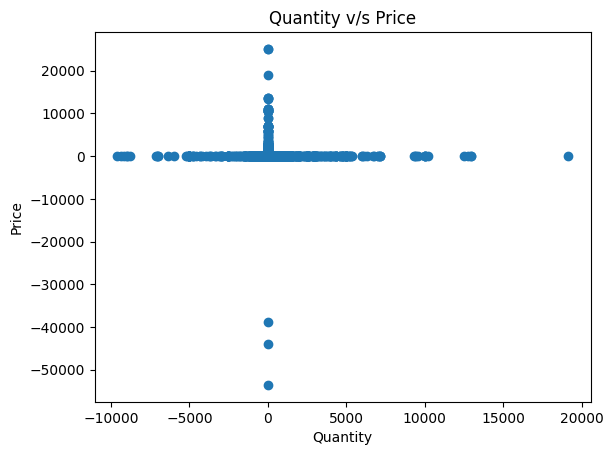

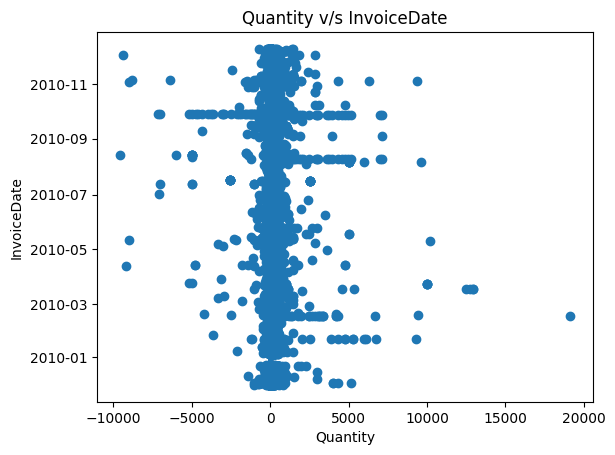

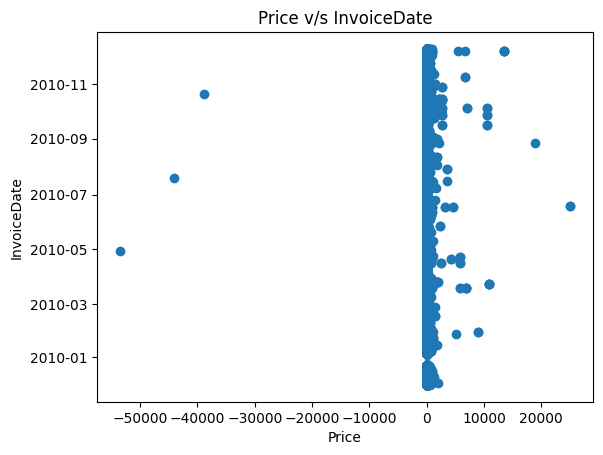

## Correlation:

## Missing Matrix:

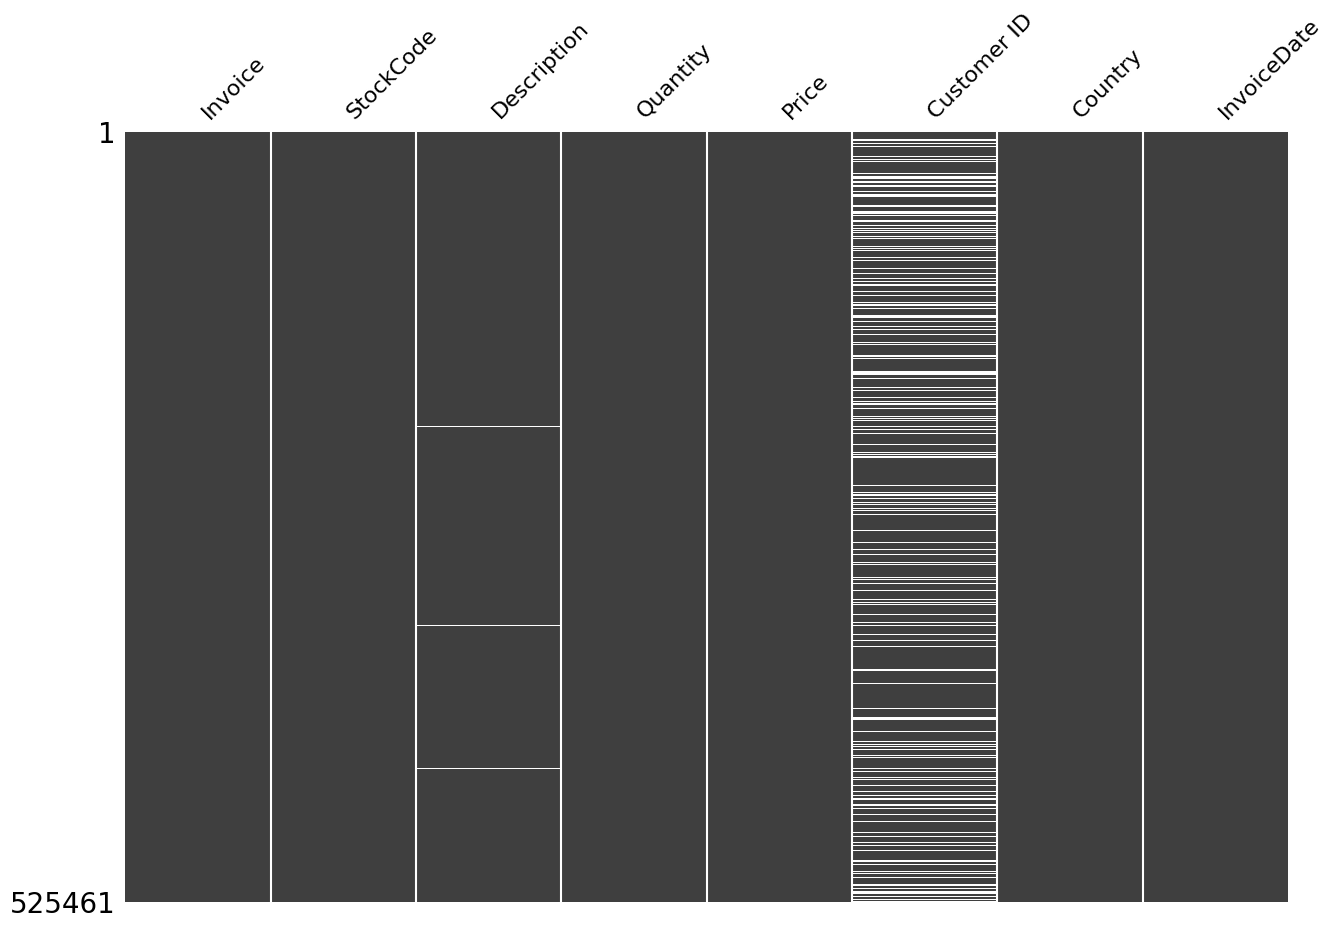

In [14]:
profile_df(df_retail)

**Respuesta:**

- En la relación de precio con cantidad, se observa un patron anormal. Cuando la cantidad es 0, se muestra que existen casos donde el precio es negativo (entre -30.000 y -52.000), como también altamente positivos (15.000 y 25.000 aprox), lo cual muestra errores de ingreso o cierto ajustes alejados de la normalidad. Además, se muestra que independiente de la cantidad, los precios siempre se mantienen en preco bajos. Esto se debe a que los precios son de forma individual del producto y en su mayoria son bajos.

- La relación Quantity vs InvoiceDate, muestra que los días que tuvo mayor cantidad de ventas fue entre 2010-05 y 2010-03. Se observa que varios días hubieron cantidad negativas, lo cual puede significa reposiciones o problemas de ingreso. Además, se observa que entre 2010-06 y 2010-07 hubo una disminución de productos vendidos.

- Price vs InvoiceDate, sugiere que en tres fecha hubieron productos con precios negativo, aprox 2010-05, 2010-06 y 2010-11, por ajustes o errores de ingreso. Se muestra que entre 2010-07 y 2010-09 aprox, se vendieron dos productos con precio mayor. También se muestra que en general los productos presentan precios bajos, con productos especificos con precios mayores. Además, entre el 2010-06 y 2010-07 hubieron ventas de productos con menor precio, a excepción de uno.

- El grafico de correlación muestra que ninguna variable presenta una correlación clara. Esto muestra que cantidad no presenta una relación lineal con precio, lo cual tiene sentido, debido que el precio es del producto individual, independiente de la cantidad comprada. La fecha de la factura tampoco muestra una relación con Quantity y precio, lo cual también se mostro en los gráficos anteriores. Faltaria analizar si existe relación no lineal.

- El grafico de valores faltantes muestra que la columna Description y Customer ID presentan valores nulos en ciertas filas. Aún asi, Description únicamente muestra tres valores nulos, lo cual es muy bajo en comparación al total de filas. El problema es que Customer ID presenta una gran cantidad de nulos, lo cual puede deberse a un error de ingreso, debido que una factura necesariamente va relacionado a un cliente. Esta gran cantidad de datos nulos demuestra que se debe análizar la opción de eliminar directamente la columna completa o mantenerla para segmentaciones.

### 1.2.3 Limpieza de Datos [1 pto]

Como pudo ver en las secciones anteriores, los datos presentan valores erroneos, es por esto que se le solicita que realice una función que permita limpiar el dataset. Realice esta función en base observaciones propias y considere como **imposible tener cantidades negativas** en las ventas. Investigue sobre métodos para eliminar outliers usando pandas

Una vez realizada la función, realice nuevamente el análisis exploratorio y comente las principales diferencias.



In [17]:
df_retail.info()

<class 'pandas.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  category      
 1   StockCode    525461 non-null  category      
 2   Description  522533 non-null  str           
 3   Quantity     525461 non-null  int64         
 4   Price        525461 non-null  float64       
 5   Customer ID  417534 non-null  category      
 6   Country      525461 non-null  object        
 7   InvoiceDate  525461 non-null  datetime64[ns]
dtypes: category(3), datetime64[ns](1), float64(1), int64(1), object(1), str(1)
memory usage: 24.5+ MB


In [18]:
df_retail["Customer ID"].isna().sum()

np.int64(107927)

In [26]:
def clean_data(df):
    df = df[df["Quantity"] > 0]  # Las cantidad tienen que ser mayores a 0, no negativas

    # Eliminan precios negativos
    df = df[df["Price"] > 0]

    # Se eliminan las 3 filas nulas de descripcion al ser pocas
    df = df.dropna(subset=["Description"])

    # Eliminar columnas customer_id al presentar muchos nulos
    df = df.drop(columns=["Customer ID"])

    # Eliminan valores outliers en precios mediante IQR
    Q1 = df["Price"].quantile(0.25)
    Q3 = df["Price"].quantile(0.75)

    IQR = Q3 - Q1

    df = df[(df["Price"] >= Q1 - 1.5 * IQR) & (df["Price"] <= Q3 + 1.5 * IQR)]

    return df

In [27]:
df_clean = clean_data(df_retail)
df_clean

,Invoice,StockCode,Description,Quantity,Price,Country,InvoiceDate
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,6.95,United Kingdom,2009-12-01 07:45:00
1,489434,79323P,PINK CHERRY LIGHTS,12,6.75,United Kingdom,2009-12-01 07:45:00
2,489434,79323W,WHITE CHERRY LIGHTS,12,6.75,United Kingdom,2009-12-01 07:45:00
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2.10,United Kingdom,2009-12-01 07:45:00
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,1.25,United Kingdom,2009-12-01 07:45:00
...,...,...,...,...,...,...,...
525456,538171,22271,FELTCRAFT DOLL ROSIE,2,2.95,United Kingdom,2010-12-09 20:01:00
525457,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1,3.75,United Kingdom,2010-12-09 20:01:00
525458,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1,3.75,United Kingdom,2010-12-09 20:01:00
525459,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2,3.75,United Kingdom,2010-12-09 20:01:00


## Bivariant Analysis:

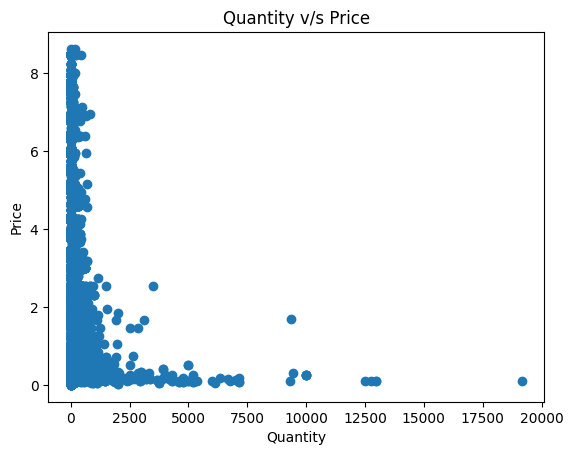

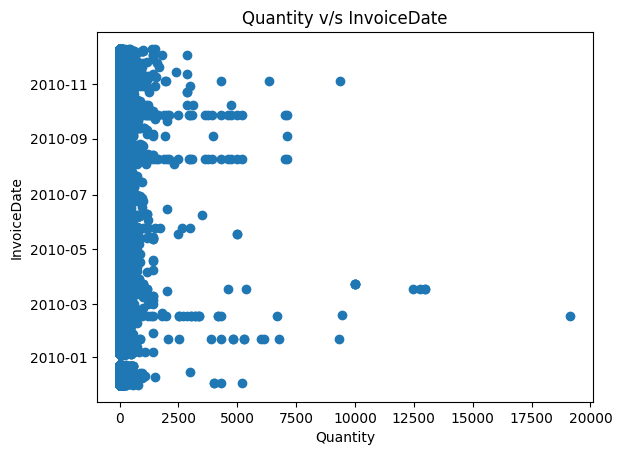

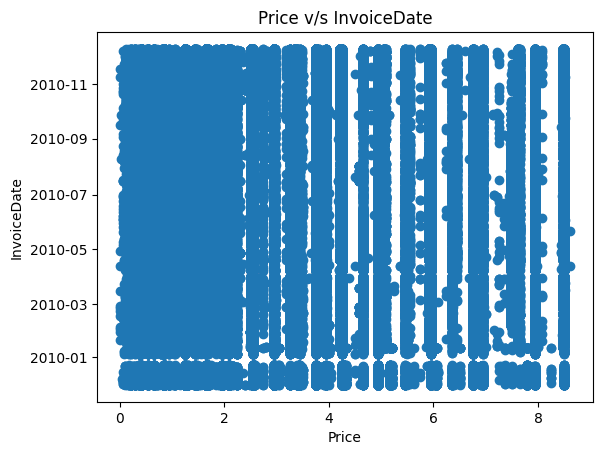

## Correlation:

## Missing Matrix:

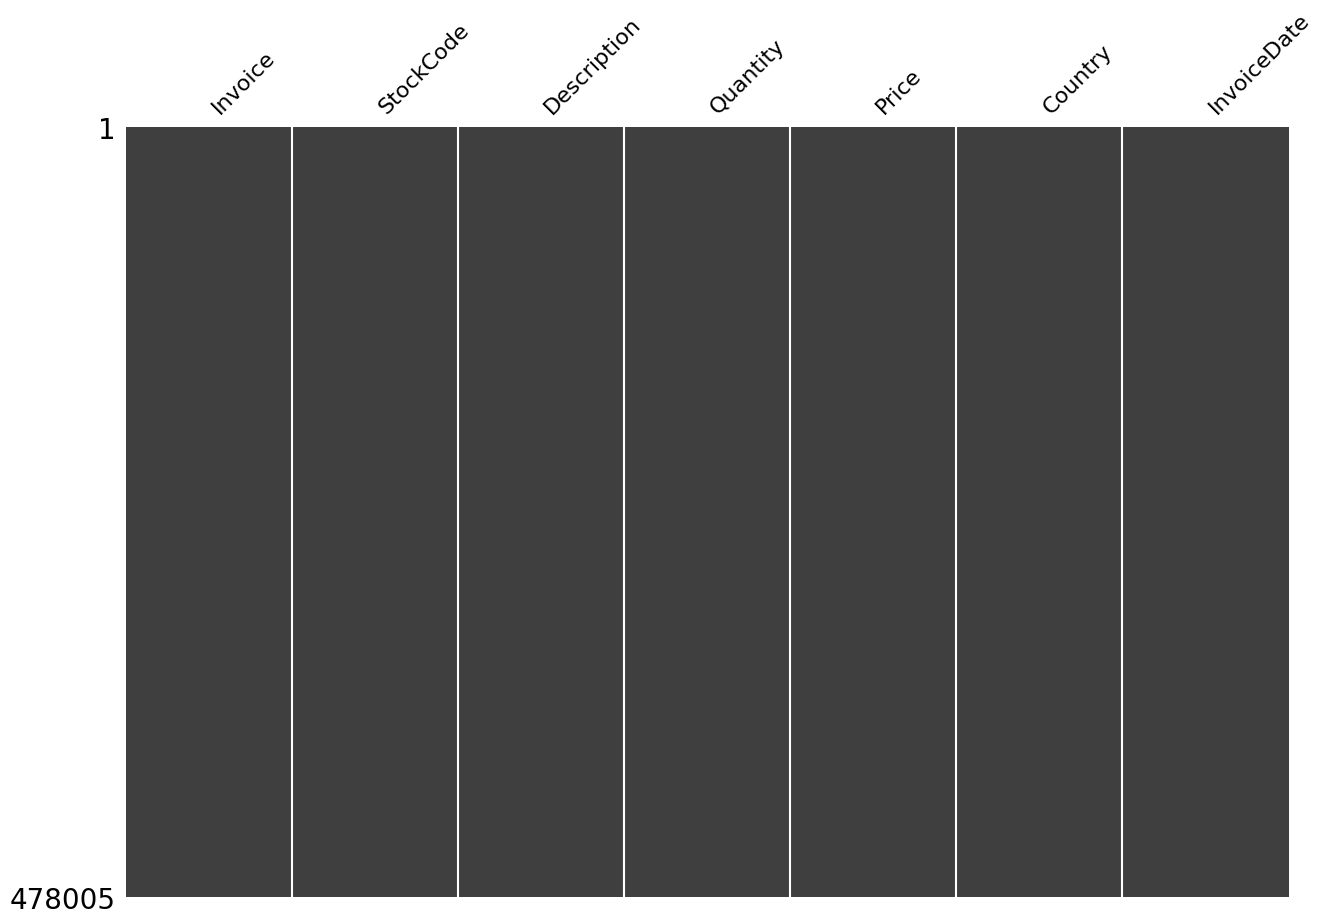

In [28]:
profile_df(df_clean)

**Respuesta:**

- En el primer grafico se observa que la mayoría de facturas presentan cantidad bajas (quantity < 1000) y precio bajos (price < 5). Cuando el precio del producto es muy bajo las cantidades compradas tienden a ser altas, demostrando que los clientes prefieren comprar en grandes cantidades de productos con precios bajos. Además, se observa que ya no se presentan valores negativos y extremos de precios al eliminar los outliers mediante IQR.

- En segundo grafico de Quantity vs InvoiceDate se muestra que ya no se presentan valores negativos en la variable cantidades. Además, nuevamente no se observa estacionalidad evidente. Se mantienen las cantidad altas, debido que puede deberse a comprar puntuales de mayoristas.

- Price vs InvoiceDate Se muestra que existe una distribución constante en el tiempo, sin grandes cambios. No se observa valores negativos ni extremos. Asimismo, se logra visualizar de mejor manera en comparación a los datos no limpios. 

- El mapa de calor de correlación muestra que a pesar de haber limpiado los datos, las correlaciones lineales entre variables siguen siendo cercana a cero, mostrando que no existe relación lineal, lo cual es esperable, al presentar un gráfico de dispersión de forma de L. De esta forma, se confirma que las variables son independientes en términos de tendencia directa, sin embargo existe cierta dependencia no lineal, donde los grandes volúmenes de venta se restringen a productos de bajo precio.

- En el último gráfico se observa que se decidio eliminar las filas nulas de Description al solo representar el 0.56% de los datos completos, lo cual no afecta la representatividad de la muestra. Por otro lado, se optó por eliminar la columna completa 'Customer ID' debido a su alta tasa de valores faltantes (22.6%). Técnicamente, se descarta que sea un caso de MCAR dada la alta frecuencia(no aleatoriedad) y distribución de los nulos, lo más probable es que se trate de datos MNAR o MAR, correspondientes a transacciones anónimas. Al ser una variable categórica de identificación única, no admite una imputación estadística confiable (como la media o mediana), y su permanencia solo degradaría la calidad del dataset.



### 1.2.4 Obtención de TOPs [0.75 ptos]

Sin considerar los comentarios realizados en la sección 1.2 , *Don Mora* les pide obtener el **Top de 30 productos que generan más ganancias** para la tienda de retail. Deben considerar todo el registro temporal presente en el dataset y entregar la información en un gráfico de barras de los ingresos/cantidades v/s el nombre de los productos (Utilice `plotly`). ¿Los artículos más vendidos son los mismos que generan más ganancias?, Comente los resultados obtenidos.

**Resultados:**

In [ ]:
# Código Aquí

### 1.2.5 Visualización del registro temporal [0,75 ptos]

El dueño del retail en su afán por saber más sobre los datos de su firma les solicita que grafiquen las ventas respecto al tiempo. Con esto les aclara que durante el día tienen muchas variaciones en sus ventas, por lo que les recomienda que consideren el registro temporal como `año-mes-día`. ¿Es posible observar datos extraños?, Comente lo que observa del gráfico.

In [ ]:
def plot_ventas(dataframe):
    pass

# Conclusión
Eso ha sido todo para el lab de hoy, recuerden que el laboratorio tiene un plazo de entrega de una semana. Cualquier duda del laboratorio, no duden en contactarnos por mail o U-cursos.

![Gracias Totales!](https://i.pinimg.com/originals/65/ae/27/65ae270df87c3c4adcea997e48f60852.gif "bruno")


<br>
<center>
<img src="https://i.kym-cdn.com/photos/images/original/001/194/195/b18.png" width=100 height=50 />
</center>
<br>

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=87110296-876e-426f-b91d-aaf681223468' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>